# Data from ROBOFLOW

In [1]:
!pip install roboflow

In [ ]:
# from roboflow import Roboflow
# rf = Roboflow(api_key="INbKeaz79oR8tec5YdFV")
# project = rf.workspace("anthonys-workspace-y3qpf").project("drone-jellyfish-3k352")
# version = project.version(5)
# dataset = version.download("coco")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Drone-Jellyfish--5 in coco:: 100%|██████████| 214/214 [00:00<00:00, 2070.09it/s]


In [ ]:
# #testing set
# from roboflow import Roboflow
# rf = Roboflow(api_key="INbKeaz79oR8tec5YdFV")
# project = rf.workspace("anthonys-workspace-y3qpf").project("jellyfish-pqc6u-ftpov-gjvb-jm40z")
# version = project.version(1)
# dataset = version.download("coco")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to jellyfish-pqc6u-ftpov-gjvb-1 in coco:: 100%|██████████| 637/637 [00:00<00:00, 2359.31it/s]


# Testing Pre-trained SAM3

In [1]:
from PIL import Image
import requests
from io import BytesIO
import sam3
from sam3.train.data.collator import collate_fn_api as collate
from sam3.model.utils.misc import copy_data_to_device
import os

import matplotlib.pyplot as plt
import numpy as np

from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

/home/anthonywang/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import torch
# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook. If your card doesn't support it, try float16 instead
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# inference mode for the whole notebook. Disable if you need gradients
torch.inference_mode().__enter__()


In [16]:
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)

In [6]:
image_path = f"/home/anthonywang/sam3/aw3813/finetuning-data/jellyfish/train/F11_42_20220827145400-0333_jpg.rf.a0ac95223f2b8284d2d3365992217bd8.jpg"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.1)
inference_state = processor.set_image(image)

found 18 object(s)


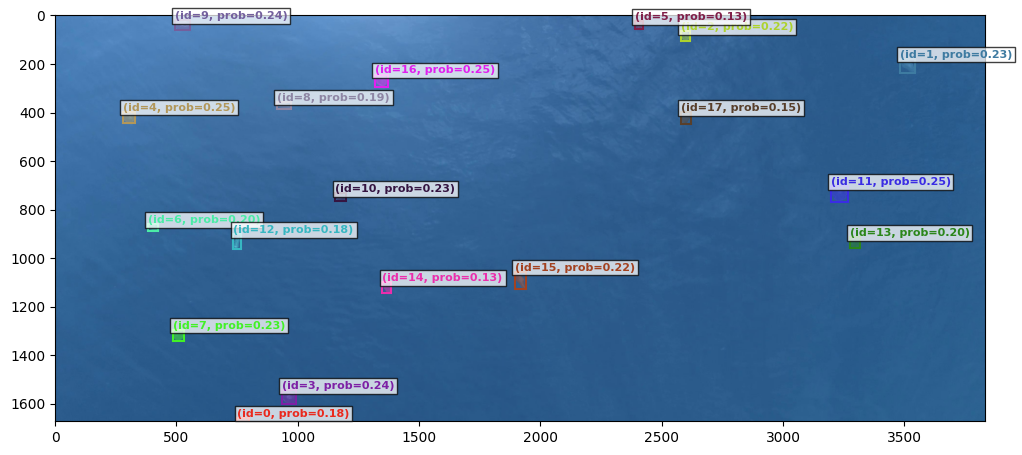

In [7]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="jellyfish")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

found 37 object(s)


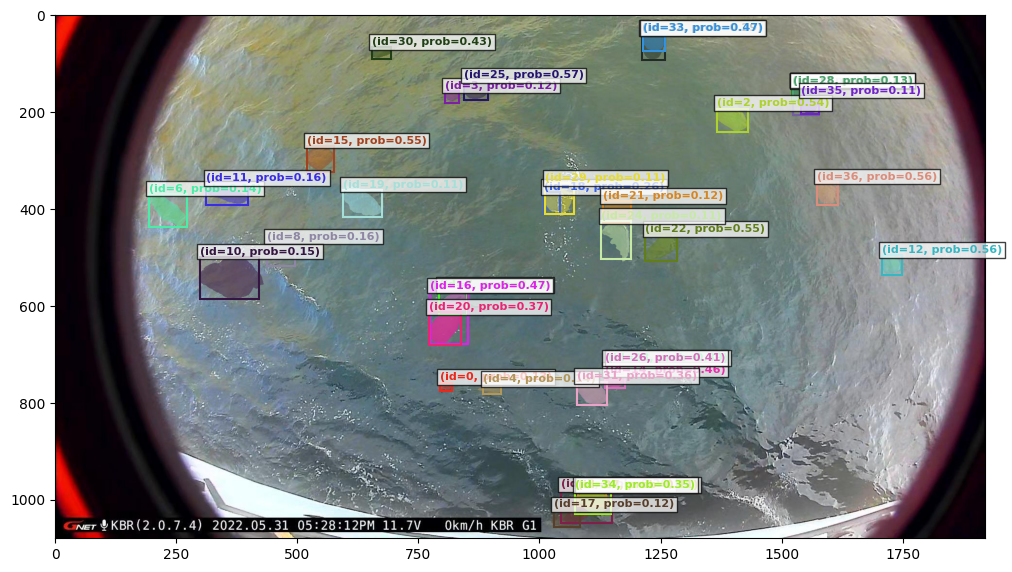

In [17]:
image_path = "/home/anthonywang/sam3/aw3813/jellyfish-pqc6u-ftpov-gjvb-1/test/2022-05-31-17_27_52_785-_mp4-141_jpg.rf.2e2376683ae80feac21d8e8cd048b4f6.jpg"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold= 0.1)
inference_state = processor.set_image(image)

processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="jellyfish")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

# **Ian's Solution**

In [8]:
missing_keys= ['segmentation_head.pixel_decoder.conv_layers.0.weight', 'segmentation_head.pixel_decoder.conv_layers.0.bias', 'segmentation_head.pixel_decoder.conv_layers.1.weight', 'segmentation_head.pixel_decoder.conv_layers.1.bias', 'segmentation_head.pixel_decoder.conv_layers.2.weight', 'segmentation_head.pixel_decoder.conv_layers.2.bias', 'segmentation_head.pixel_decoder.norms.0.weight', 'segmentation_head.pixel_decoder.norms.0.bias', 'segmentation_head.pixel_decoder.norms.1.weight', 'segmentation_head.pixel_decoder.norms.1.bias', 'segmentation_head.pixel_decoder.norms.2.weight', 'segmentation_head.pixel_decoder.norms.2.bias', 'segmentation_head.mask_predictor.mask_embed.layers.0.weight', 'segmentation_head.mask_predictor.mask_embed.layers.0.bias', 'segmentation_head.mask_predictor.mask_embed.layers.1.weight', 'segmentation_head.mask_predictor.mask_embed.layers.1.bias', 'segmentation_head.mask_predictor.mask_embed.layers.2.weight', 'segmentation_head.mask_predictor.mask_embed.layers.2.bias', 'segmentation_head.cross_attend_prompt.in_proj_weight', 'segmentation_head.cross_attend_prompt.in_proj_bias', 'segmentation_head.cross_attend_prompt.out_proj.weight', 'segmentation_head.cross_attend_prompt.out_proj.bias', 'segmentation_head.cross_attn_norm.weight', 'segmentation_head.cross_attn_norm.bias', 'segmentation_head.semantic_seg_head.weight', 'segmentation_head.semantic_seg_head.bias', 'segmentation_head.instance_seg_head.weight', 'segmentation_head.instance_seg_head.bias']

In [10]:
from sam3.train.utils.checkpoint_utils import load_state_dict_into_model
checkpoint_path = "/home/anthonywang/sam3/experiments/jellyfish_run1/checkpoints/checkpoint.pt"
model = build_sam3_image_model(load_from_HF=True, enable_segmentation=True)  # NOTE HERE YOU LOAD THE DEFAULT SEGMENTATION HEAD
checkpoint = torch.load(checkpoint_path, map_location="cuda")
model = load_state_dict_into_model(model=model, state_dict=checkpoint["model"], ignore_missing_keys=missing_keys)

In [11]:
image_path = f"/home/anthonywang/sam3/aw3813/finetuning-data/jellyfish/train/F11_42_20220827145400-0333_jpg.rf.a0ac95223f2b8284d2d3365992217bd8.jpg"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold= 0.1)
inference_state = processor.set_image(image)

found 19 object(s)


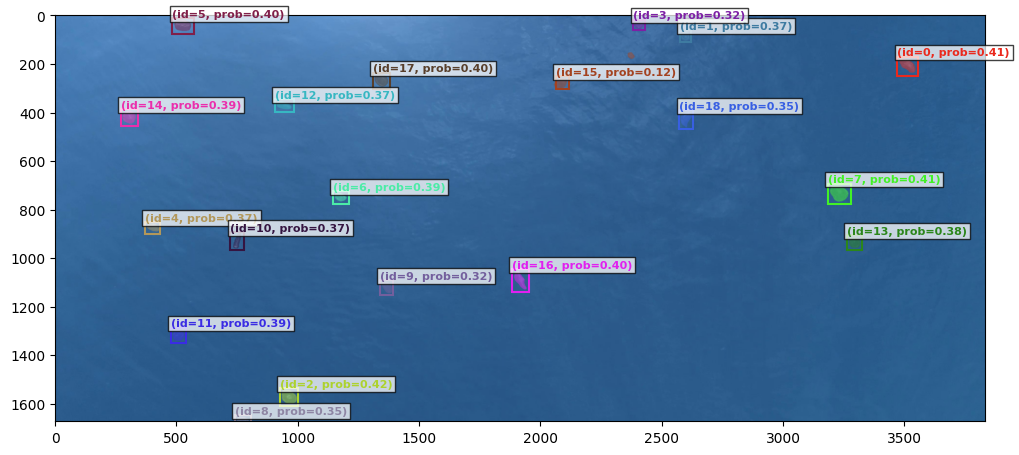

In [12]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="jellyfish")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

### How about on unseen data? 

In [14]:
image_path = "/home/anthonywang/sam3/aw3813/jellyfish-pqc6u-ftpov-gjvb-1/test/2022-05-31-17_27_52_785-_mp4-141_jpg.rf.2e2376683ae80feac21d8e8cd048b4f6.jpg"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold= 0.1)
inference_state = processor.set_image(image)


found 21 object(s)


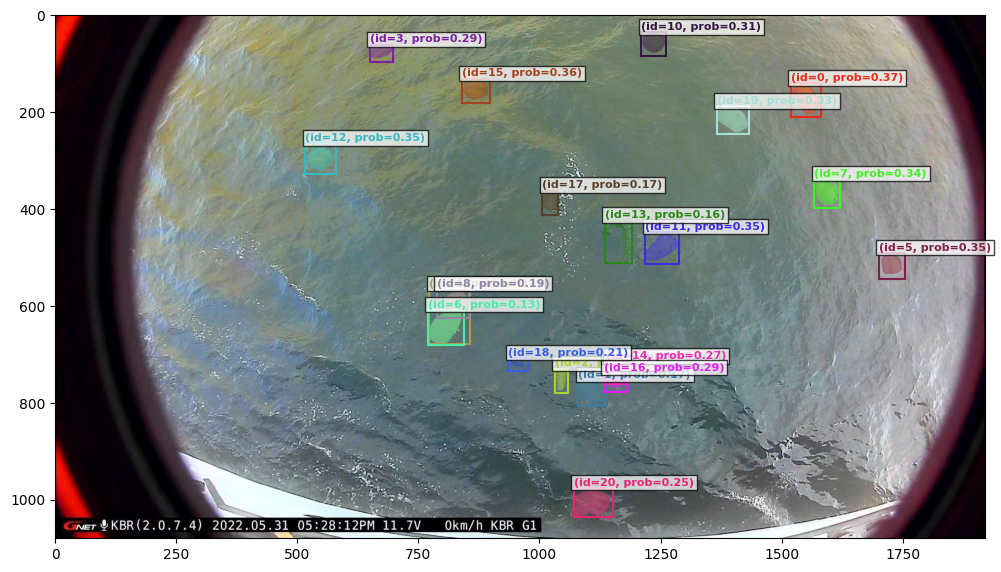

In [15]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="jellyfish")

img0 = Image.open(image_path)
plot_results(img0, inference_state)